# Exercises XP: Introduction to LLMs

Week 12, Day 1

## 👩‍🏫👩🏿‍🏫 What you'll learn
- Understand what Large Language Models (LLMs) can do.
- Review the Transformer architecture and the tokenization pipeline.
- Differentiate between pretraining and fine-tuning.
- Generate text with a pretrained language model.

## 🛠️ What you will create
- Markdown answers describing key NLP concepts.
- Python code that loads GPT-2 (a causal LM) and performs basic tokenization and generation.

## 🌟 Exercise 1 · What are Large Language Models?

### 1.1 Define LLMs

A **Large Language Model (LLM)** is a very large neural network, almost always based on the **Transformer** architecture, trained on huge amounts of text (books, websites, code...) to **predict the next token** of a text given everything before it. By repeating this simple task billions of times, the model learns grammar, vocabulary, facts about the world, reasoning patterns and writing styles. "Large" refers both to the number of parameters (from hundreds of millions, like GPT-2, to hundreds of billions) and to the size of the training data.

Because generating the next word well requires "understanding" the context, a single LLM can be used for many language tasks without being designed specifically for each one:
- **text generation** (stories, emails, articles) and **conversation** (chatbots such as ChatGPT or Claude);
- **summarisation**, **translation**, **question answering** and information extraction;
- **classification** of texts (sentiment, topic, spam);
- **code** generation and explanation;
- rewriting, correcting and reformulating text.

LLMs are designed to understand and produce human language in a flexible way. Their limits: they can produce fluent but **wrong** answers ("hallucinations"), they reproduce biases present in their training data, and their knowledge stops at their training date.

### 1.2 Install core libraries
Run once to install `transformers`, `torch`, and supporting utilities exactly as in the instructions.

In [1]:
%pip install --quiet transformers matplotlib --upgrade

Note: you may need to restart the kernel to use updated packages.


### 1.3 Load GPT for causal text generation
Declare the model name, tokenizer, and model weights.

In [2]:
from transformers import AutoTokenizer, AutoModelForCausalLM, pipeline, set_seed
import torch
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

# 2. Loading a pretrained model and tokenizer
model_name = "gpt2"  # GPT-2 is used here for demonstration; can be replaced with models like "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(model_name)

if None in (model_name, tokenizer, model):
    raise ValueError("Fill in model_name, tokenizer, and model before continuing.")

print(f"\nModel '{model_name}' loaded successfully!")
print("""
GPT-2 is a causal language model, meaning it predicts the next word in a sequence.
It has been trained on a diverse dataset and can generate coherent, contextually relevant text.
""")
print(f"Number of parameters: {model.num_parameters():,}")
print(f"Vocabulary size: {tokenizer.vocab_size:,} tokens | Maximum context: {model.config.n_positions} tokens")
print(f"Architecture: {model.config.n_layer} Transformer decoder blocks, {model.config.n_head} attention heads, "
      f"embeddings of size {model.config.n_embd}")


Model 'gpt2' loaded successfully!

GPT-2 is a causal language model, meaning it predicts the next word in a sequence.
It has been trained on a diverse dataset and can generate coherent, contextually relevant text.

Number of parameters: 124,439,808
Vocabulary size: 50,257 tokens | Maximum context: 1024 tokens
Architecture: 12 Transformer decoder blocks, 12 attention heads, embeddings of size 768


GPT-2 "small" has **124 million parameters**, a vocabulary of **50,257 tokens** and can read up to **1,024 tokens** of context. It is a stack of **12 Transformer decoder blocks**: in each block, a **masked self-attention** layer lets every token look at all the previous tokens (but not the future ones) to build a contextual representation, followed by a feed-forward network. The last layer turns the representation of the last position into a probability for each of the 50,257 possible next tokens.

## 🌟 Exercise 2 · Transformer Architecture and Tokenization

**What is tokenization?** A neural network cannot read letters or words directly: it only works with numbers. **Tokenization** is the first step of the pipeline: the text is cut into small pieces called **tokens**, and each token is replaced by its **ID**, its position in a fixed vocabulary. Tokens are not always whole words: GPT-2 uses **Byte-Pair Encoding (BPE)**, which keeps frequent words as a single token ("the", "model") and splits rare or long words into frequent sub-word pieces ("token" + "ization"). This keeps the vocabulary at a reasonable size (50,257 tokens) while being able to represent *any* text, including new words, typos or other languages. Then, inside the Transformer, each token ID is mapped to an **embedding vector** (plus a position embedding), and these vectors are what the attention layers process.

Original Text: Tokenization helps transformers understand unbelievably complex sentences!
Tokens: ['Token', 'ization', 'Ġhelps', 'Ġtransform', 'ers', 'Ġunderstand', 'Ġunbelievably', 'Ġcomplex', 'Ġsentences', '!']
Token IDs: [30642, 1634, 5419, 6121, 364, 1833, 48943, 3716, 13439, 0]
7 words -> 10 tokens


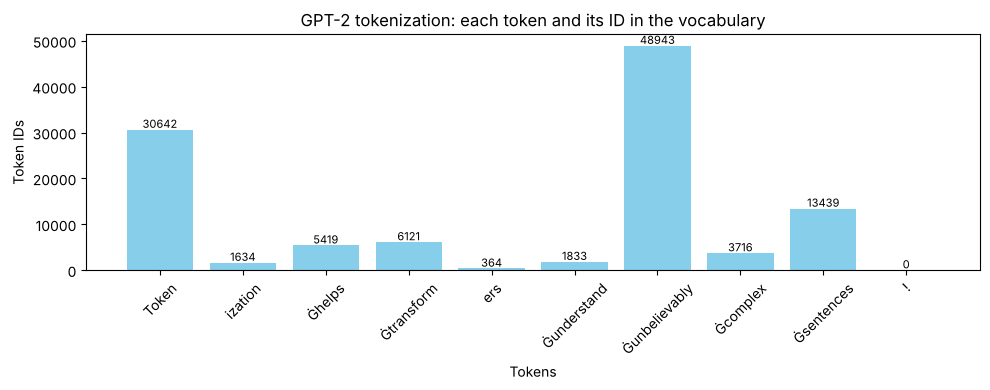

In [3]:
text = "Tokenization helps transformers understand unbelievably complex sentences!"
if text is None:
    raise ValueError("Define the variable `text` with a short sentence.")

tokens = tokenizer.tokenize(text)                     # split the text into sub-word tokens
token_ids = tokenizer.convert_tokens_to_ids(tokens)   # map each token to its vocabulary ID

print(f"Original Text: {text}")
print(f"Tokens: {tokens}")
print(f"Token IDs: {token_ids}")
print(f"{len(text.split())} words -> {len(tokens)} tokens")

x_label = "Tokens"
y_label = "Token IDs"
title = "GPT-2 tokenization: each token and its ID in the vocabulary"

if None in (x_label, y_label, title):
    raise ValueError("Set x_label, y_label, and title before plotting.")

plt.figure(figsize=(10, 4))
plt.bar(range(len(tokens)), token_ids, color="skyblue")
plt.xticks(range(len(tokens)), tokens, rotation=45)
plt.xlabel(x_label)
plt.ylabel(y_label)
plt.title(title)
for i, tid in enumerate(token_ids):
    plt.text(i, tid + 400, str(tid), ha="center", fontsize=8)
plt.tight_layout()
plt.show()

*(The bars are positioned by index so that a token appearing twice would get two bars; the token strings are used as tick labels.)*

The 7 words of the sentence become **10 tokens**: most words (" helps", " understand", " complex", " sentences", and even " unbelievably") are single tokens, while some are split into frequent pieces: "Tokenization" → "Token" + "ization" and "transformers" → " transform" + "ers". The punctuation mark "!" is its own token (ID 0, the first entry of the vocabulary). In general, very frequent pieces have **small IDs** (the BPE vocabulary was built by merging the most frequent pairs first, e.g. "ers" = 364), whereas rarer tokens have larger IDs (" unbelievably" = 48943).

In [4]:
# The reverse operation: decoding the IDs gives back exactly the original text
print("Decoded:", tokenizer.decode(token_ids))
print("Same as original:", tokenizer.decode(token_ids) == text)

# The tokenizer can also do everything in one call and return PyTorch tensors ready for the model
encoded = tokenizer(text, return_tensors="pt")
print("input_ids tensor:", encoded["input_ids"])
print("attention_mask:", encoded["attention_mask"])

Decoded: Tokenization helps transformers understand unbelievably complex sentences!
Same as original: True
input_ids tensor: 

tensor([[30642,  1634,  5419,  6121,   364,  1833, 48943,  3716, 13439,     0]])
attention_mask: tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1]])


## 🌟 Exercise 3 · Token IDs and special prefixes

In [5]:
if 'tokens' not in globals() or 'token_ids' not in globals():
    raise ValueError("Run Exercise 2 to define `tokens` and `token_ids` first.")

print(f"{'position':<10}{'token':<18}{'token id':<10}{'decoded'}")
for position, (token, token_id) in enumerate(zip(tokens, token_ids)):
    print(f"{position:<10}{token:<18}{token_id:<10}{repr(tokenizer.decode([token_id]))}")

position  token             token id  decoded
0         Token             30642     'Token'
1         ization           1634      'ization'
2         Ġhelps            5419      ' helps'
3         Ġtransform        6121      ' transform'
4         ers               364       'ers'
5         Ġunderstand       1833      ' understand'
6         Ġunbelievably     48943     ' unbelievably'
7         Ġcomplex          3716      ' complex'
8         Ġsentences        13439     ' sentences'
9         !                 0         '!'


In [6]:
# The same word with and without a leading space gives different tokens
for word in ["model", " model", "Paris", " Paris"]:
    t = tokenizer.tokenize(word)
    print(f"{word!r:<10} -> tokens {t} -> ids {tokenizer.convert_tokens_to_ids(t)}")

'model'    -> tokens ['model'] -> ids [19849]
' model'   -> tokens ['Ġmodel'] -> ids [2746]
'Paris'    -> tokens ['Paris'] -> ids [40313]
' Paris'   -> tokens ['ĠParis'] -> ids [6342]


**What does the `Ġ` prefix indicate?** In GPT-2's byte-level BPE vocabulary, the character **`Ġ` stands for a space** placed *before* the token. GPT-2 does not delete spaces: it attaches each space to the beginning of the word that follows it. So `Ġhelps` means " helps" (a new word starting after a space), while a token without `Ġ` is either the very first word of the text or the **continuation of the previous word** (like `ization` in "Tokenization" or `ers` in "transformers").

This is why `"model"` and `" model"` have **different IDs** (19849 vs 2746), and the same for `"Paris"` (40313) and `" Paris"` (6342): for the model, a word at the start of a sentence and the same word in the middle of a sentence are two different tokens. The `Ġ` symbol is just how the space byte is displayed in the vocabulary (GPT-2 maps bytes such as the space to visible characters); when the IDs are decoded, it becomes a normal space again, so the original text is recovered exactly. Other tokenizers use similar markers, e.g. `▁` in SentencePiece (T5, Llama) or `##` for word continuations in BERT's WordPiece.

## 🌟 Exercise 4 · Pretraining vs. Fine-Tuning

Transformers like GPT are trained in **two phases**:

**1. Pretraining** - learning the language in general.
The model starts with random weights and is trained on a **huge, unlabeled** corpus (billions of words from books, Wikipedia, websites, code). The task is **self-supervised**: the labels come from the text itself. For GPT-style (causal) models, the task is to predict the **next token** from all the previous ones; for BERT-style models it is to guess **masked words** in a sentence. This phase is extremely expensive (thousands of GPUs for weeks), but it is done once. At the end, the model has learned grammar, vocabulary, facts and general reasoning patterns: it is a **general-purpose "foundation" model** (like the `gpt2` checkpoint we just loaded), but it is not specialised in any task.

**2. Fine-tuning** - adapting the model to a specific task.
We start from the pretrained weights and continue training on a **much smaller, labeled, task-specific** dataset: for example a few thousand movie reviews labeled positive/negative for sentiment analysis, question–answer pairs, medical texts, or conversations written by humans to make an assistant follow instructions (instruction tuning, then RLHF for chatbots like ChatGPT). Training is short and cheap (minutes to hours on one GPU), uses a small learning rate so that the general knowledge is not destroyed, and sometimes only updates part of the weights (e.g. a new classification head, or adapters like LoRA).

**In short:** pretraining gives the model general knowledge of the language from massive unlabeled data; fine-tuning specialises this knowledge for a particular task or behaviour with a small labeled dataset. This **transfer learning** approach is why we can get excellent results on a new task with little data: we do not start from zero.

## 🌟 Exercise 5 · Generate simple text

Create a fresh prompt, run the generator, and observe how the model extends your sentence token by token.

In [7]:
set_seed(42)  # make the sampled outputs reproducible

generator = pipeline(
    "text-generation",
    model=model,
    tokenizer=tokenizer,
    device=0 if torch.cuda.is_available() else -1,
)

input_text = "In the future, artificial intelligence will help doctors"
if input_text is None:
    raise ValueError("Set `input_text` before generating.")

gen_kwargs = {
    "max_new_tokens": 60,   # length of the continuation
    "temperature": 0.8,     # < 1: a bit more focused than pure sampling
    "top_p": 0.95,          # nucleus sampling: only sample from the most likely tokens covering 95% of the probability
    "do_sample": True,
    "pad_token_id": tokenizer.eos_token_id,
}

output_ids = generator(input_text, **gen_kwargs)   # call the generator
output_text = output_ids[0]["generated_text"]      # extract the text string

print(f"Input: {input_text}")
print(f"Generated Output: {output_text}")

Input: In the future, artificial intelligence will help doctors
Generated Output: In the future, artificial intelligence will help doctors more easily identify a patient's health condition, he said, and it will also help doctors to help patients better understand how they're feeling.

"The ability to provide better treatment is an important part of our healthcare system, but there are many other areas where we need to invest in that,"


In [8]:
# The same thing without the pipeline: model.generate() works directly on token IDs
inputs = tokenizer(input_text, return_tensors="pt")
with torch.no_grad():
    greedy_ids = model.generate(**inputs, max_new_tokens=40, do_sample=False, pad_token_id=tokenizer.eos_token_id)
print("Greedy decoding (always the most likely next token):")
print(tokenizer.decode(greedy_ids[0], skip_special_tokens=True))

Greedy decoding (always the most likely next token):
In the future, artificial intelligence will help doctors diagnose and treat diseases that are not related to the disease itself.

"We're going to see a lot of new ways to treat diseases that are not related to the disease itself," said Dr


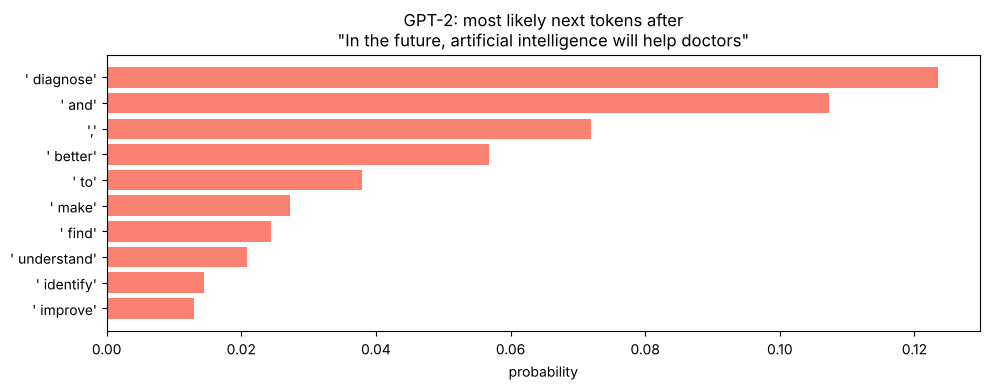

In [9]:
# How the model chooses the next token: probabilities of the 10 most likely tokens after the prompt
with torch.no_grad():
    logits = model(**inputs).logits[0, -1]       # scores for the token that comes after the prompt
probs = torch.softmax(logits, dim=-1)
top = torch.topk(probs, 10)
top_tokens = [repr(tokenizer.decode([i])) for i in top.indices]

plt.figure(figsize=(10, 4))
plt.barh(top_tokens[::-1], top.values.numpy()[::-1], color="salmon")
plt.xlabel("probability")
plt.title(f"GPT-2: most likely next tokens after\n\"{input_text}\"")
plt.tight_layout()
plt.show()

In [10]:
# Effect of the temperature on the generated style
for temperature in [0.3, 0.8, 1.5]:
    set_seed(0)
    out = generator(input_text, max_new_tokens=40, temperature=temperature, top_p=0.95, do_sample=True,
                    pad_token_id=tokenizer.eos_token_id)[0]["generated_text"]
    print(f"--- temperature = {temperature} ---\n{out}\n")

--- temperature = 0.3 ---
In the future, artificial intelligence will help doctors, nurses, and other professionals to better understand the health of patients.

"We are looking at a lot of different approaches to this," said Dr. David K. Kowalski,



--- temperature = 0.8 ---
In the future, artificial intelligence will help doctors understand what their patients have gone through, how they have been treated, and the kinds of treatments they're receiving. But it also can help physicians to make diagnoses.

And it will also help



--- temperature = 1.5 ---
In the future, artificial intelligence will help doctors avoid dangerous complications with Alzheimer's and stroke, according to Stanford neurosurgeon Andrew Hausner. Such a machine would be "almost immediately a breakthrough in clinical diagnosis in a large swath of Alzheimer's



**Observations on the generation:**
- The model continues the prompt **token by token**: at each step it computes a probability for each of the 50,257 tokens (see the chart of the 10 most likely next tokens) and picks one, then adds it to the input and repeats.
- With sampling (temperature 0.8, top-p 0.95), GPT-2 produces a fluent, grammatical continuation that stays on topic (doctors, patients, diagnosis, healthcare), in the style of a news article with quotes, because a large part of its training data (WebText) is made of web articles. The content is plausible but **invented**: the quotes and names are not real, a typical "hallucination" of language models.
- **Greedy decoding** (always taking the most likely token) is deterministic but quickly becomes repetitive and loops ("treat diseases that are not related to the disease itself" appears twice).
- **Temperature** changes the style the most: at **0.3** the text is safe, generic and close to greedy decoding; at **0.8** it is varied but coherent; at **1.5** it becomes more surprising and specific (Alzheimer's, a named neurosurgeon) but also less reliable and more likely to drift or make no sense in longer texts. **`max_new_tokens`** only controls the length: longer outputs give the model more room to drift away from the prompt. **`top_p`** limits sampling to the most likely tokens and avoids very improbable words.
- GPT-2 small is a relatively old and small model (124M parameters, 2019): it has no instruction tuning, so it continues text rather than answering questions, and it does not really "know" what is true. Modern LLMs are much larger and fine-tuned to follow instructions (Exercise 4).

> **Learning point**
> Compare the generated continuation with your expectations. Which knobs (temperature, max tokens) change the style the most?